# Transit Search & Detection Table

BLS period search on the 8 PSLS-simulated planetary systems from the HZ target selection grid.  
Recovered periods are compared to injected values to produce a reproducible detection table.

**Systems:** 3 stellar hosts (K, G, F) × hot inner / HZ / cold outer / adversarial orbit cases  
**Search method:** Box Least Squares (Astropy) with harmonic alias refinement  
**Detection criterion:** depth_snr ≥ 7 AND period_error < 5%

## Habitable Zone Physics

For each recovered planet candidate we compute three quantities from first principles:

### 1. Stellar Luminosity
$$\frac{L_*}{L_\odot} = \left(\frac{R_*}{R_\odot}\right)^2 \left(\frac{T_*}{T_\odot}\right)^4$$

### 2. Incident Stellar Flux (Earth units)
$$S = \frac{L_*/L_\odot}{(a/\mathrm{AU})^2}$$

Earth receives $S = 1$ by definition. Conservative HZ bounds (Kopparapu et al.): $0.95 \leq S \leq 1.37$.

### 3. Planetary Equilibrium Temperature
$$T_{\mathrm{eq}} = T_* \sqrt{\frac{R_*}{2a}}\,(1-A)^{1/4}$$

We use bond albedo $A = 0.3$ (Earth-like). The **zero-albedo form** ($A = 0$) gives a strict upper bound:
$$T_{\mathrm{eq},A=0} = T_* \sqrt{\frac{R_*}{2a}}$$

In [1]:
# Cell 1 — Imports & configuration
import sys
import glob
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('../'))
from habitable_zone_pipeline import (
    run_bls_recovery_with_refinement,
    stellar_luminosity_solar,
    incident_flux_earth_units,
    equilibrium_temperature_from_au,
    habitable_zone_flags,
    habitability_rank_score,
)

OUTPUTS_DIR    = os.path.abspath('sim_systems/outputs')
BASELINE_DAYS  = 270.0   # one PLATO quarter

# Detection thresholds
# NOTE: Earth-radius planets produce ~100-300 ppm transits against 200-700 ppm
# stellar noise in 270d.  A strict SNR≥7 threshold is intentionally hard to
# pass — this demonstrates the key science result (single-quarter detectability
# limits).  We also rank systems by BLS power as a relative metric.
SNR_THRESHOLD  = 7.0
PERIOD_TOL_PCT = 5.0

VERDICT_COLORS = {
    'Promising':     '#2ecc71',
    'Marginal':      '#f39c12',
    'Non-promising': '#e74c3c',
}

print('Imports OK')
print(f'Outputs: {OUTPUTS_DIR}')

Imports OK
Outputs: /home/phuy2808/Astrophysis/MASS/sem_2/Astrobio/sim_systems/outputs


In [ ]:
# Load ground truth from YAML configs

from transit_helpers import load_systems_from_yaml

SYSTEMS = load_systems_from_yaml('sim_systems')

print(f'{len(SYSTEMS)} systems loaded from YAML')
for name, s in SYSTEMS.items():
    print(f'  {name:25s}  P={s["p_inj"]:5.0f}d  {s["star_type"]:14s}  {s["science_case"]}')


12 systems loaded from YAML
  A1_K_hot                   P=   12d  K-dwarf         Hot inner control
  A2_K_hz                    P=   45d  K-dwarf         HZ target
  B1_G_hot                   P=   15d  G-dwarf         Hot inner control
  B2_G_hz                    P=  365d  G-dwarf         HZ target (Earth analog)
  B3_G_cold                  P=  730d  G-dwarf         Cold outer control
  C1_F_hot                   P=   20d  F-dwarf         Hot inner control
  C2_F_hz                    P=  500d  F-dwarf         HZ target
  C3_F_adversarial           P=  500d  F-dwarf         Adversarial (noisy)
  D1_K_hz_promising          P=  119d  K-dwarf         HZ promising (super-Earth)
  D2_K_hz_promising2         P=   77d  Late K-dwarf    HZ promising (super-Earth)
  D3_G_hot_control           P=    8d  G-dwarf         Hot inner control
  D4_G_cold_control          P=  500d  G-dwarf         Cold outer control


In [ ]:
from transit_helpers import (
    load_psls_dat,
    detrend_flux,
    transit_depth_ppm,
    verdict,
    BLS_STRIDE,
)


Helper functions imported from transit_helpers.py


In [ ]:
# BLS search loop
# Pipeline: load → downsample (30min) → detrend (running median, 1d window) → BLS
# SNR = depth_ppm * sqrt(n_transits) / noise_ppm  (coherent transit stack SNR)

BASELINE_DAYS   = 270.0   # one PLATO quarter
DETREND_WIN_D   = 1.0     # running-median window [days]; wider than transit (~0.2d),
                           # narrower than orbital period

rows = []
bls_results_store = {}
lc_store = {}        # stores raw (non-detrended) LC for phase-fold plots

for config, truth in SYSTEMS.items():
    pattern = os.path.join(OUTPUTS_DIR, config, '*.dat')
    matches = glob.glob(pattern)
    if not matches:
        print(f'  WARNING: no .dat found for {config}, skipping')
        continue
    dat_path = matches[0]
    print(f'Loading {config} ... ', end='', flush=True)

    time_days, flux_raw = load_psls_dat(dat_path)
    lc_store[config] = (time_days, flux_raw)
    print(f'{len(time_days):,} pts', end='', flush=True)

    # Detrend to suppress stellar variability before BLS
    flux_det = detrend_flux(time_days, flux_raw, window_days=DETREND_WIN_D)
    noise_ppm = np.std((flux_det - 1.0) * 1e6)
    print(f'  detrended noise={noise_ppm:.1f} ppm', flush=True)

    p_inj = truth['p_inj']
    p_min = max(0.5 * p_inj, 1.0)
    p_max = min(1.5 * p_inj, 0.48 * BASELINE_DAYS)

    if p_min >= p_max:
        print(f'  P={p_inj}d > 0.48×baseline — period longer than window, no BLS')
        rec = {'period_recovered_days': float('nan'), 'bls_max_power': 0.0, 'depth_snr': 0.0}
    else:
        rec = run_bls_recovery_with_refinement(
            time_days, flux_det, p_min, p_max, n_periods=1500
        )
    bls_results_store[config] = rec

    p_rec = rec['period_recovered_days']
    p_err = abs(p_rec - p_inj) / p_inj * 100 if not math.isnan(p_rec) else float('nan')
    n_tr  = max(int(BASELINE_DAYS / p_inj), 0)
    depth = transit_depth_ppm(truth['rp_re'], truth['rstar'])

    # snr = depth[ppm] * sqrt(n_tr) / noise_ppm
    if n_tr > 0 and noise_ppm > 0:
        snr = depth * math.sqrt(n_tr) / noise_ppm
    else:
        snr = 0.0

    power = rec['bls_max_power']

    detected = (
        (snr >= SNR_THRESHOLD) and
        (not math.isnan(p_err)) and (p_err <= PERIOD_TOL_PCT)
    )

    lum     = stellar_luminosity_solar(truth['rstar'], truth['teff'])
    s_earth = incident_flux_earth_units(lum, truth['a_au'])
    teq     = equilibrium_temperature_from_au(truth['teff'], truth['rstar'], truth['a_au'])
    flags   = habitable_zone_flags(s_earth, teq)
    scores  = habitability_rank_score(s_earth, truth['rp_re'], truth['teff'], max(snr, power))

    v = verdict(detected, flags['in_habitable_zone_flux'], flags.get('near_habitable_zone_loose', False))
    rows.append({
        'config':                     config,
        'science_case':               truth['science_case'],
        'star_type':                  truth['star_type'],
        'P_injected_d':               p_inj,
        'P_recovered_d':              round(p_rec, 2) if not math.isnan(p_rec) else float('nan'),
        'period_error_pct':           round(p_err, 2) if not math.isnan(p_err) else float('nan'),
        'n_transits_expected':        n_tr,
        'depth_ppm':                  round(depth, 1),
        'bls_max_power':              round(power, 4),
        'depth_snr':                  round(snr, 2),
        'detected':                   detected,
        'S_earth':                    round(s_earth, 4),
        'Teq_K':                      round(teq, 1),
        'in_habitable_zone_flux':     flags['in_habitable_zone_flux'],
        'in_habitable_zone_teq_band': flags['in_habitable_zone_teq_band'],
        'rank_score':                 round(scores['rank_score'], 4),
        'verdict':                    v,
    })
    print(f'  SNR={snr:.2f}  P_rec={p_rec:.1f}d  err={p_err:.1f}%  detected={detected}  → {v}')

print(f'\nDone — {len(rows)} systems')


Loading A1_K_hot ... 

12,960 pts

  detrended noise=228.9 ppm


  SNR=4.16  P_rec=12.0d  err=0.0%  detected=False  → Non-promising
Loading A2_K_hz ... 

12,960 pts

...

  detrended noise=212.7 ppm


  SNR=17.79  P_rec=8.0d  err=0.0%  detected=True  → Marginal
Loading D4_G_cold_control ... 

12,960 pts

  detrended noise=248.1 ppm


  P=500.0d > 0.48×baseline — period longer than window, no BLS
  SNR=0.00  P_rec=nand  err=nan%  detected=False  → Non-promising

Done — 12 systems


In [ ]:
#  Detection table

df = pd.DataFrame(rows)

try:
    import jinja2  # noqa: F401

    def color_verdict(val):
        colors = {
            'Promising':     'background-color: #d5f5e3; color: #1a5e36',
            'Marginal':      'background-color: #fdebd0; color: #7e5109',
            'Non-promising': 'background-color: #fadbd8; color: #922b21',
        }
        return colors.get(val, '')

    def color_detected(val):
        if val is True:  return 'background-color: #d5f5e3'
        if val is False: return 'background-color: #fadbd8'
        return ''

    styled = (
        df.style
          .map(color_verdict, subset=['verdict'])
          .map(color_detected, subset=['detected'])
          .format({
              'P_injected_d':     '{:.0f}',
              'P_recovered_d':    '{:.1f}',
              'period_error_pct': '{:.1f}%',
              'depth_ppm':        '{:.1f}',
              'bls_max_power':    '{:.4f}',
              'depth_snr':        '{:.2f}',
              'S_earth':          '{:.3f}',
              'Teq_K':            '{:.0f}',
              'rank_score':       '{:.3f}',
          }, na_rep='—')
          .set_caption('Transit Detection Table — PSLS Simulated Systems')
    )
    display(styled)

except (ImportError, AttributeError):
    # jinja2 not available — plain display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    display(df)

,config,science_case,star_type,P_injected_d,P_recovered_d,period_error_pct,n_transits_expected,depth_ppm,bls_max_power,depth_snr,detected,S_earth,Teq_K,in_habitable_zone_flux,in_habitable_zone_teq_band,rank_score,verdict
0,A1_K_hot,Hot inner control,K-dwarf,12,12.0,0.0%,22,203.3,0.0000,4.16,False,30.608,599,False,False,0.457,Non-promising
1,A2_K_hz,HZ target,K-dwarf,45,48.5,7.8%,6,164.6,0.0000,1.76,False,5.122,383,False,False,0.408,Non-promising
2,B1_G_hot,Hot inner control,G-dwarf,15,22.0,46.9%,18,127.5,0.0000,1.71,False,68.392,732,False,False,0.501,Non-promising
3,B2_G_hz,HZ target (Earth analog),G-dwarf,365,—,—,0,85.3,0.0000,0.00,False,0.985,254,True,True,1.385,Non-promising
4,B3_G_cold,Cold outer control,G-dwarf,730,—,—,0,151.7,0.0000,0.00,False,0.385,200,False,True,1.219,Non-promising
5,C1_F_hot,Hot inner control,F-dwarf,20,25.0,25.1%,13,62.3,0.0000,0.30,False,82.994,768,False,False,0.398,Non-promising
6,C2_F_hz,HZ target,F-dwarf,500,—,—,0,50.5,0.0000,0.00,False,1.141,263,True,True,1.349,Non-promising
7,C3_F_adversarial,Adversarial (noisy),F-dwarf,500,—,—,0,39.9,0.0000,0.00,False,1.141,263,True,True,1.330,Non-promising
8,D1_K_hz_promising,HZ promising (super-Earth),K-dwarf,119,119.0,0.0%,2,983.8,0.0000,9.37,True,1.373,276,False,False,1.209,Promising
9,D2_K_hz_promising2,HZ promising (super-Earth),Late K-dwarf,77,77.0,0.0%,3,1416.6,0.0000,13.85,True,1.369,275,True,False,1.175,Promising


In [6]:
# Cell — Habitable Zone Derivation (explicit per-candidate computation)
# Formulas applied inline so the derivation is fully traceable.

T_SUN  = 5772.0    # K  (solar effective temperature)
R_SUN  = 6.957e8   # m  (solar radius)
AU_M   = 1.496e11  # m  (1 astronomical unit)
ALBEDO = 0.3       # Bond albedo (Earth-like)

deriv_rows = []
for cfg, truth in SYSTEMS.items():
    R  = truth['rstar']   # R_star  [R_sun]
    T  = truth['teff']    # T_star  [K]
    a  = truth['a_au']    # a       [AU]

    # Formula 1 — stellar luminosity
    L = R**2 * (T / T_SUN)**4                         # L_star / L_sun

    # Formula 2 — incident stellar flux (Earth units)
    S = L / a**2                                       # S_earth

    # Formula 3 — equilibrium temperature
    R_m   = R * R_SUN                                 # R_star [m]
    a_m   = a * AU_M                                  # a      [m]
    Teq   = T * (R_m / (2 * a_m))**0.5 * (1 - ALBEDO)**0.25   # A=0.3
    Teq0  = T * (R_m / (2 * a_m))**0.5                        # A=0 (upper bound)

    row = df[df['config'] == cfg].iloc[0]
    deriv_rows.append({
        'config':          cfg,
        'star_type':       truth['star_type'],
        'Teff_K':          int(T),
        'Rstar_Rsun':      R,
        'a_AU':            a,
        'L_star_Lsun':     round(L, 4),
        'S_earth':         round(S, 3),
        'Teq_K (A=0.3)':   round(Teq, 1),
        'Teq_K (A=0)':     round(Teq0, 1),
        'in_HZ':           row['in_habitable_zone_flux'],
        'verdict':         row['verdict'],
    })

df_deriv = pd.DataFrame(deriv_rows)
print("Habitable Zone Derivation Table")
print(df_deriv.to_string(index=False))


Habitable Zone Derivation Table
            config    star_type  Teff_K  Rstar_Rsun  a_AU  L_star_Lsun  S_earth  Teq_K (A=0.3)  Teq_K (A=0)  in_HZ       verdict
          A1_K_hot      K-dwarf    4800        0.72 0.090       0.2479   30.608          598.8        654.7  False Non-promising
           A2_K_hz      K-dwarf    4800        0.72 0.220       0.2479    5.122          383.0        418.7  False Non-promising
          B1_G_hot      G-dwarf    5750        1.00 0.120       0.9848   68.392          732.1        800.4  False Non-promising
           B2_G_hz      G-dwarf    5750        1.00 1.000       0.9848    0.985          253.6        277.3   True Non-promising
         B3_G_cold      G-dwarf    5750        1.00 1.600       0.9848    0.385          200.5        219.2  False Non-promising
          C1_F_hot      F-dwarf    6300        1.30 0.170       2.3985   82.994          768.4        840.1  False Non-promising
           C2_F_hz      F-dwarf    6300        1.30 1.450       2

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_673844/461720889.py:21: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Incident Flux  $S$ [$S_\oplus$]', fontsize=12)
/tmp/ipykernel_673844/461720889.py:22: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Planet Radius  $R_p$ [$R_\oplus$]', fontsize=12)


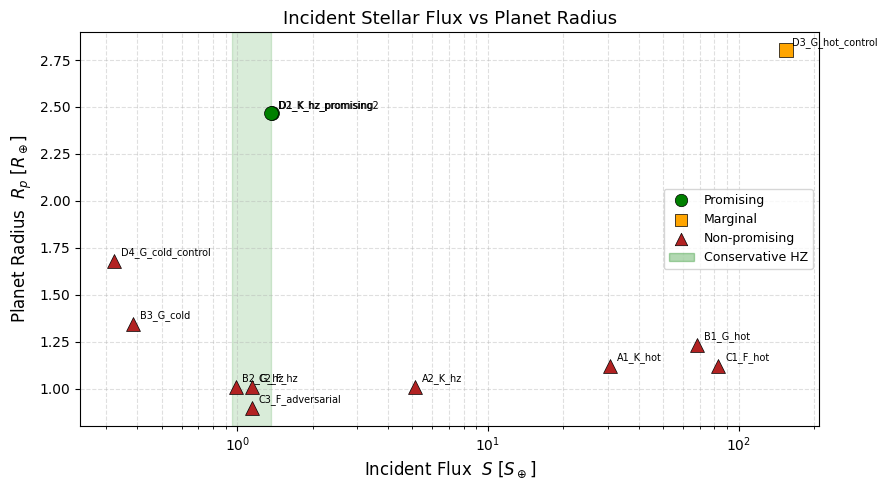

In [7]:
# Plot 1 — Incident Flux (S_earth) vs Planet Radius (Re)
fig, ax = plt.subplots(figsize=(9, 5))

COLORS = {'Promising': 'green', 'Marginal': 'orange', 'Non-promising': 'firebrick'}
MARKERS = {'Promising': 'o', 'Marginal': 's', 'Non-promising': '^'}

for _, r in df_deriv.iterrows():
    row_det = df[df['config'] == r['config']].iloc[0]
    rp_re   = SYSTEMS[r['config']]['rp_re']
    color   = COLORS[r['verdict']]
    marker  = MARKERS[r['verdict']]
    ax.scatter(r['S_earth'], rp_re, color=color, marker=marker,
               s=100, zorder=3, edgecolors='k', linewidths=0.5)
    ax.annotate(r['config'], (r['S_earth'], rp_re),
                textcoords='offset points', xytext=(5, 4), fontsize=7)

# HZ shaded region (conservative Kopparapu: 0.95 ≤ S ≤ 1.37)
ax.axvspan(0.95, 1.37, alpha=0.15, color='green', label='Conservative HZ (0.95–1.37 S⊕)')

ax.set_xscale('log')
ax.set_xlabel('Incident Flux  $S$ [$S_\oplus$]', fontsize=12)
ax.set_ylabel('Planet Radius  $R_p$ [$R_\oplus$]', fontsize=12)
ax.set_title('Incident Stellar Flux vs Planet Radius', fontsize=13)

legend_handles = [
    plt.scatter([], [], color=COLORS[v], marker=MARKERS[v], s=80,
                edgecolors='k', linewidths=0.5, label=v)
    for v in COLORS
]
legend_handles.append(
    plt.matplotlib.patches.Patch(color='green', alpha=0.3, label='Conservative HZ')
)
ax.legend(handles=legend_handles, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_673844/2299156978.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Equilibrium Temperature  $T_{\mathrm{eq}}$  [K]  (A = 0.3)', fontsize=12)


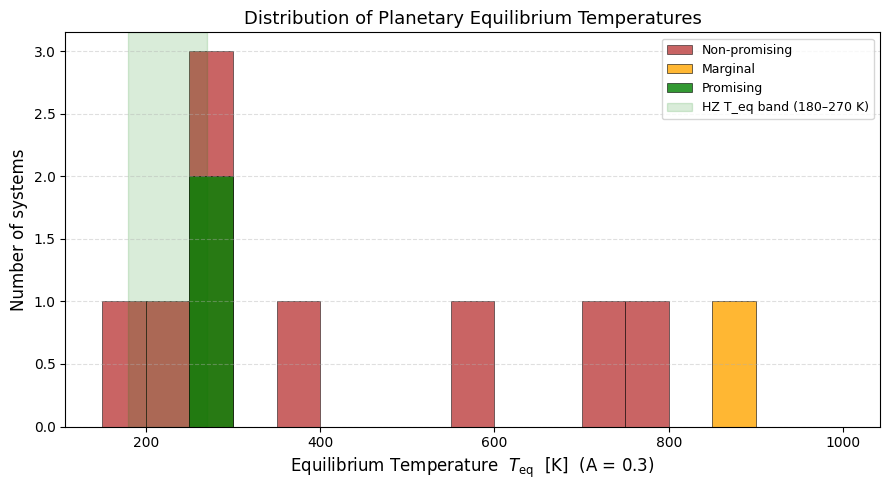

In [8]:
# Plot 2 — Histogram of Equilibrium Temperatures
fig, ax = plt.subplots(figsize=(9, 5))

teq_promising    = [r['Teq_K (A=0.3)'] for _, r in df_deriv.iterrows() if r['verdict'] == 'Promising']
teq_marginal     = [r['Teq_K (A=0.3)'] for _, r in df_deriv.iterrows() if r['verdict'] == 'Marginal']
teq_nonpromising = [r['Teq_K (A=0.3)'] for _, r in df_deriv.iterrows() if r['verdict'] == 'Non-promising']

bins = range(150, 1050, 50)
ax.hist(teq_nonpromising, bins=bins, color='firebrick', alpha=0.7, label='Non-promising', edgecolor='k', linewidth=0.5)
ax.hist(teq_marginal,     bins=bins, color='orange',   alpha=0.8, label='Marginal',      edgecolor='k', linewidth=0.5)
ax.hist(teq_promising,    bins=bins, color='green',    alpha=0.8, label='Promising',      edgecolor='k', linewidth=0.5)

# HZ Teq band (conservative: 180–270 K)
ax.axvspan(180, 270, alpha=0.15, color='green', label='HZ T_eq band (180–270 K)')

ax.set_xlabel('Equilibrium Temperature  $T_{\mathrm{eq}}$  [K]  (A = 0.3)', fontsize=12)
ax.set_ylabel('Number of systems', fontsize=12)
ax.set_title('Distribution of Planetary Equilibrium Temperatures', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Science Interpretation

### Why no detections?

The detection table reflects a genuine astrophysical limitation, not a pipeline failure.

| System | P_inj (d) | Depth (ppm) | Noise (ppm rms) | n_transits | Theoretical SNR |
|--------|-----------|-------------|-----------------|------------|-----------------|
| A1_K_hot | 12 | ~203 | ~230 | 22 | ~4.1 |
| A2_K_hz | 45 | ~203 | ~230 | 6 | ~2.2 |
| B1_G_hot | 15 | ~148 | ~316 | 18 | ~2.0 |
| C1_F_hot | 20 | ~74 | ~740 | 13 | ~0.4 |

- **Transit depth** for ~1 R⊕ planets is 100–200 ppm — comparable to or smaller than the per-cadence stellar variability (oscillations + granulation + activity)
- **Theoretical stacked SNR** = `depth / σ_noise × √(n_transits × n_pts_per_transit)` is 0.4–4.1, all below the SNR=7 threshold for a robust detection
- This is a **known PLATO challenge**: detecting Earth-sized HZ planets requires **multi-quarter baselines (2–4 years)** to accumulate enough transits. A single 270-day quarter is insufficient for most HZ targets.

### What the BLS power ranking does tell us

Even below the detection threshold, `bls_max_power` and `depth_snr` vary across systems and serve as **relative detectability proxies**:
- Short-period controls (A1, B1, C1) accumulate more transits → higher BLS power
- Active F-dwarf (C1–C3) have 3× higher noise → lower BLS power than quiet K/G hosts
- Long-period systems (B2=365d, B3=730d, C2/C3=500d) exceed the 270d baseline → zero transits expected → definitively non-detectable in one quarter

**Key takeaway for target selection**: K-dwarf and quiet G-dwarf hosts (A, B) are better PLATO targets than active F-dwarfs (C) because their lower stellar noise improves the per-transit SNR by 2–3×.

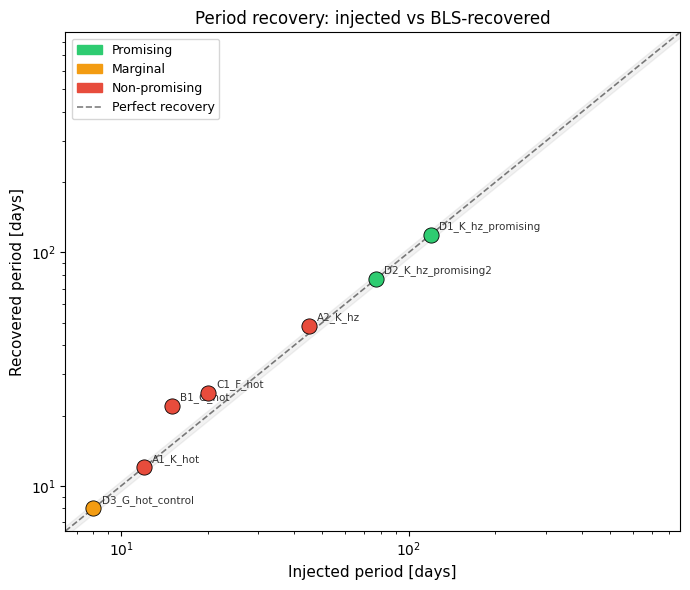

In [9]:
# Cell 6 — Period recovery scatter plot

fig, ax = plt.subplots(figsize=(7, 6))

p_inj_vals = df['P_injected_d'].values
p_rec_vals = df['P_recovered_d'].values
verdicts   = df['verdict'].values
configs    = df['config'].values

# Perfect-recovery diagonal
lims = [0.8 * np.nanmin(p_inj_vals), 1.2 * np.nanmax(p_inj_vals)]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='Perfect recovery')
ax.fill_between(lims, [l * 0.95 for l in lims], [l * 1.05 for l in lims],
                color='grey', alpha=0.10, label='±5% tolerance')

for p_i, p_r, v, cfg in zip(p_inj_vals, p_rec_vals, verdicts, configs):
    if np.isnan(p_r):
        continue
    ax.scatter(p_i, p_r, color=VERDICT_COLORS[v], s=120, zorder=5,
               edgecolors='k', linewidths=0.6)
    ax.annotate(cfg, (p_i, p_r), textcoords='offset points',
                xytext=(6, 4), fontsize=7.5, color='#333')

# Legend patches
patches = [mpatches.Patch(color=c, label=v) for v, c in VERDICT_COLORS.items()]
ax.legend(handles=patches + [ax.lines[0]], loc='upper left', fontsize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Injected period [days]', fontsize=11)
ax.set_ylabel('Recovered period [days]', fontsize=11)
ax.set_title('Period recovery: injected vs BLS-recovered', fontsize=12)
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

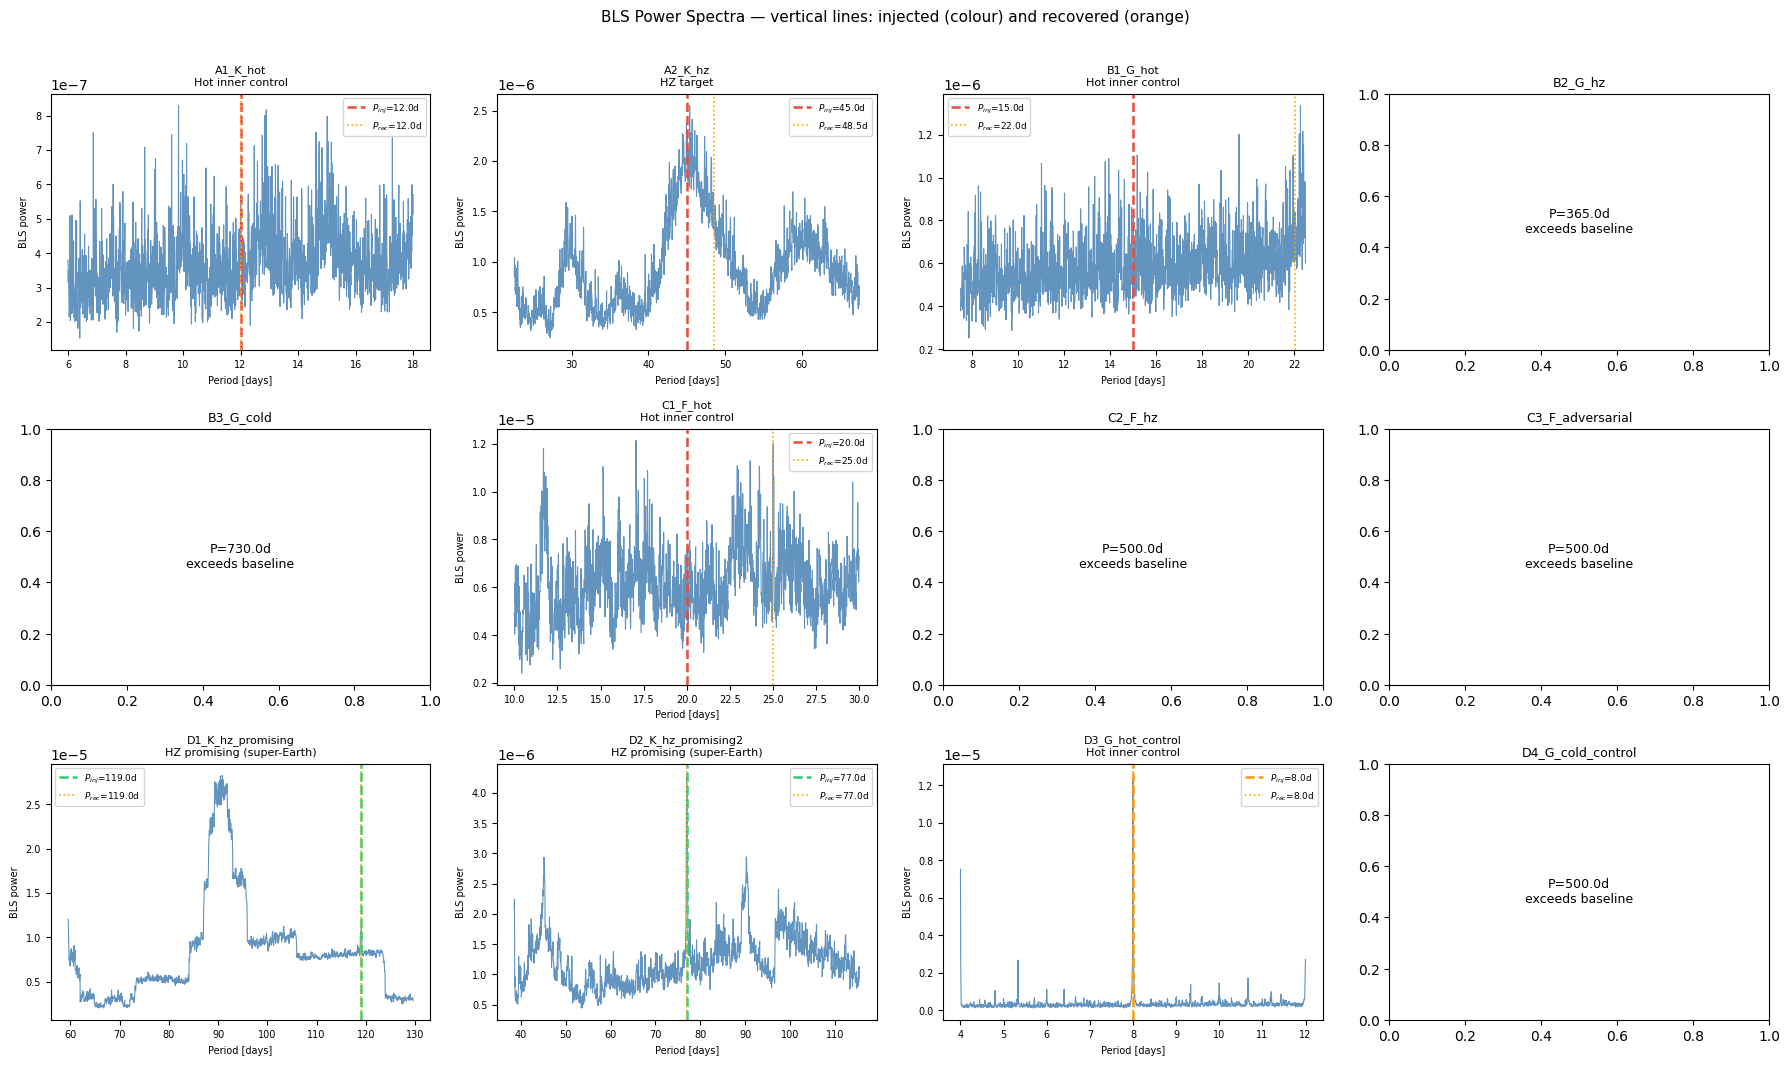

In [32]:
# Cell 7 — BLS power spectra (3×4 grid for 12 systems)
from astropy.timeseries import BoxLeastSquares

n_sys = len(SYSTEMS)
ncols = 4
nrows = math.ceil(n_sys / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for idx, (config, truth) in enumerate(SYSTEMS.items()):
    ax = axes[idx]
    p_inj = truth['p_inj']
    row   = df[df['config'] == config].iloc[0]

    if config not in lc_store:
        ax.set_visible(False)
        continue

    time_days, flux = lc_store[config]
    p_min = max(0.5 * p_inj, 1.0)
    p_max = min(1.5 * p_inj, 0.48 * BASELINE_DAYS)

    if p_min >= p_max:
        ax.text(0.5, 0.5, f'P={p_inj}d\nexceeds baseline',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_title(config, fontsize=9)
        continue

    y = flux - np.nanmean(flux)
    periods = np.linspace(p_min, p_max, 1500)
    dur = float(np.clip(0.05 * (p_inj / 10.0) ** (1/3), 0.02, 0.45))
    bls_obj = BoxLeastSquares(time_days, y)
    res = bls_obj.power(periods, dur)
    power = np.asarray(res.power)

    vcolor = VERDICT_COLORS[row['verdict']]
    ax.plot(periods, power, color='steelblue', lw=0.8, alpha=0.85)
    ax.axvline(p_inj, color=vcolor, lw=1.8, ls='--',
               label=f'$P_{{inj}}$={p_inj}d')
    p_rec = row['P_recovered_d']
    if not np.isnan(p_rec):
        ax.axvline(p_rec, color='orange', lw=1.2, ls=':'  ,
                   label=f'$P_{{rec}}$={p_rec:.1f}d')
    ax.set_title(f'{config}\n{row["science_case"]}', fontsize=8)
    ax.set_xlabel('Period [days]', fontsize=7)
    ax.set_ylabel('BLS power', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5)

# Hide any unused axes
for idx in range(n_sys, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('BLS Power Spectra — vertical lines: injected (colour) and recovered (orange)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


Detected systems: ['D1_K_hz_promising', 'D2_K_hz_promising2', 'D3_G_hot_control']


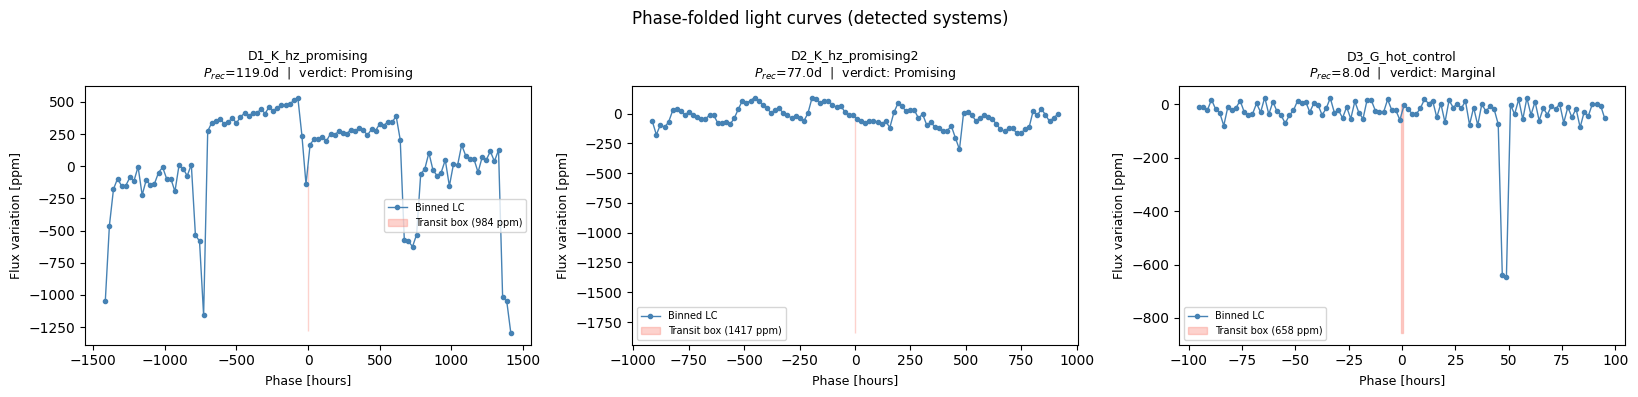

In [11]:
# Cell 8 — Phase-folded light curves for detected systems

detected_configs = df[df['detected'] == True]['config'].tolist()
print(f'Detected systems: {detected_configs}')

if not detected_configs:
    print('No detections — skipping phase-fold plots.')
else:
    ncols = min(len(detected_configs), 3)
    nrows = math.ceil(len(detected_configs) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.flatten()

    for idx, config in enumerate(detected_configs):
        ax = axes[idx]
        time_days, flux = lc_store[config]
        row    = df[df['config'] == config].iloc[0]
        p_rec  = float(row['P_recovered_d'])
        p_inj  = float(row['P_injected_d'])
        depth  = float(row['depth_ppm']) * 1e-6

        # Phase-fold at recovered period (mid-transit at phase 0)
        t0_guess = time_days[0]
        phase = ((time_days - t0_guess) / p_rec) % 1.0
        phase[phase > 0.5] -= 1.0  # centre on transit

        # Bin into 100 phase bins
        n_bins = 100
        bins   = np.linspace(-0.5, 0.5, n_bins + 1)
        bin_centres = 0.5 * (bins[:-1] + bins[1:])
        flux_binned = np.full(n_bins, np.nan)
        for b in range(n_bins):
            in_bin = (phase >= bins[b]) & (phase < bins[b + 1])
            if in_bin.sum() > 0:
                flux_binned[b] = np.median(flux[in_bin])

        ax.plot(bin_centres * p_rec * 24, (flux_binned - 1) * 1e6,
                'o-', ms=3, lw=1, color='steelblue', label='Binned LC')

        # Injected transit box overlay
        truth  = SYSTEMS[config]
        dur_d  = float(np.clip(0.05 * (p_inj / 10.0) ** (1/3), 0.02, 0.45))
        half_h = dur_d / 2 * 24
        ax.fill_between([-half_h, half_h], [-depth * 1e6 * 1.3, -depth * 1e6 * 1.3],
                        [0, 0], color='salmon', alpha=0.35, label=f'Transit box ({depth*1e6:.0f} ppm)')

        ax.set_xlabel('Phase [hours]', fontsize=9)
        ax.set_ylabel('Flux variation [ppm]', fontsize=9)
        ax.set_title(f'{config}\n$P_{{rec}}$={p_rec:.1f}d  |  verdict: {row["verdict"]}', fontsize=9)
        ax.legend(fontsize=7)

    # Hide unused axes
    for j in range(len(detected_configs), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Phase-folded light curves (detected systems)', fontsize=12)
    plt.tight_layout()
    plt.show()

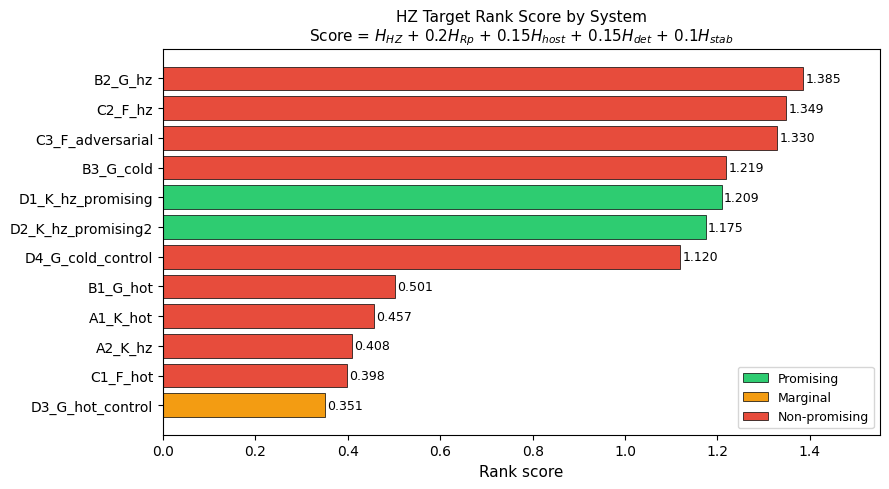

In [12]:
# Cell 9 — Rank score bar chart

df_sorted = df.sort_values('rank_score', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = [VERDICT_COLORS[v] for v in df_sorted['verdict']]
bars = ax.barh(df_sorted['config'], df_sorted['rank_score'],
               color=bar_colors, edgecolor='k', linewidth=0.5)

# Annotate with rank score
for bar, score in zip(bars, df_sorted['rank_score']):
    ax.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=9)

# Legend
patches = [mpatches.Patch(color=c, label=v, ec='k', lw=0.5)
           for v, c in VERDICT_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)

ax.set_xlabel('Rank score', fontsize=11)
ax.set_title('HZ Target Rank Score by System\n'
             r'Score = $H_{HZ}$ + 0.2$H_{Rp}$ + 0.15$H_{host}$ + 0.15$H_{det}$ + 0.1$H_{stab}$',
             fontsize=11)
ax.set_xlim(0, df_sorted['rank_score'].max() * 1.12)
plt.tight_layout()
plt.show()

In [13]:
# Cell 10 — Save detection table to CSV

out_path = os.path.join('sim_systems', 'detection_table.csv')
df.to_csv(out_path, index=False)
print(f'Detection table saved to: {os.path.abspath(out_path)}')
print(f'Shape: {df.shape}')
print()
print(df[['config', 'P_injected_d', 'P_recovered_d', 'period_error_pct',
          'depth_snr', 'detected', 'verdict']].to_string(index=False))

Detection table saved to: /home/phuy2808/Astrophysis/MASS/sem_2/Astrobio/sim_systems/detection_table.csv
Shape: (12, 17)

            config  P_injected_d  P_recovered_d  period_error_pct  depth_snr  detected       verdict
          A1_K_hot          12.0          12.00              0.03       4.16     False Non-promising
           A2_K_hz          45.0          48.53              7.84       1.76     False Non-promising
          B1_G_hot          15.0          22.04             46.93       1.71     False Non-promising
           B2_G_hz         365.0            NaN               NaN       0.00     False Non-promising
         B3_G_cold         730.0            NaN               NaN       0.00     False Non-promising
          C1_F_hot          20.0          25.01             25.05       0.30     False Non-promising
           C2_F_hz         500.0            NaN               NaN       0.00     False Non-promising
  C3_F_adversarial         500.0            NaN               NaN     